# 14차시 보강: 전이학습 전략 비교 실습

이 실습에서는 **3가지 전이학습 전략**을 비교합니다:
1. **Freeze (전체 동결)**: 백본 전체를 고정하고 분류기만 학습
2. **Partial (부분 해제)**: 마지막 블록(layer4)과 분류기만 학습
3. **Full (전체 해제)**: 모든 층을 학습

**목표**: 소규모 데이터셋(3,000개)에서 각 전략의 성능을 비교하고 최적 전략을 찾기

In [1]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 4.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no suc

In [2]:
# 필요 라이브러리 설치

!pip install torchviz | tail -n 1
!pip install torchinfo | tail -n 1

In [ ]:
# 런타임 다시 시작하세요

In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib

# 나눔고딕 폰트 경로 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fontprop = fm.FontProperties(fname=font_path)

# matplotlib 기본 폰트로 지정
matplotlib.rc('font', family='NanumGothic')

# 마이너스 부호 깨짐 방지
matplotlib.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정 완료:", matplotlib.rcParams['font.family'])

한글 폰트 설정 완료: ['NanumGothic']


In [2]:
# 필수 라이브러리 임포트
import torch  # PyTorch 메인 라이브러리
import torch.nn as nn  # 신경망 모듈
import torch.optim as optim  # 최적화 알고리즘
from torchvision import datasets, transforms, models  # 비전 관련 도구
from torch.utils.data import DataLoader, Subset  # 데이터 로더
import numpy as np  # 수치 연산
import random  # 랜덤 함수

# GPU 사용 가능 여부 확인 및 디바이스 설정
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'사용 디바이스: {device}')

# 재현성을 위한 시드 설정 (매번 동일한 결과를 얻기 위함)
torch.manual_seed(0)  # PyTorch 시드
np.random.seed(0)  # NumPy 시드
random.seed(0)  # Python random 시드

# CUDA 사용 시 추가 재현성 설정
if torch.cuda.is_available():
    torch.cuda.manual_seed(0)  # CUDA 시드
    torch.backends.cudnn.deterministic = True  # 결정적 알고리즘 사용
    torch.backends.cudnn.benchmark = False  # 벤치마크 비활성화

print('환경 설정 완료!')
print(f'PyTorch 버전: {torch.__version__}')

사용 디바이스: cuda
환경 설정 완료!
PyTorch 버전: 2.11.0+cu128


텍스트 전처리

In [3]:
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    # 이미지 60-100% 영역을 무작위로 잘라 224*224 이미지로 조정
    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),
    transforms.Normalize(mean = (0.485, 0.456, 0.406),
                         std = (0.229, 0.224, 0.225))
    # rgb 각 채널의 평균, 표준편차
])

transform_test = transforms.Compose([
    transforms.Resize(256),     # 이미지를 256*256 사이즈 변형
    transforms.CenterCrop(224),
    # 중앙을 224*224 이미지로 잘라냄(증강 없이 고정된 영역 사용)

    transforms.ToTensor(),
    transforms.Normalize(mean = (0.485, 0.456, 0.406),
                         std = (0.229, 0.224, 0.225))
])

In [ ]:
# 코드 따라쳐보기

# 훈련데이터 전처리
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6,1.0)),
    transforms.RandomHorizontalFlip(p=0.5), # 디폴트값임
    transforms.ToTensor(),
    transforms.Normalize(mean = (0.485, 0.456, 0.406), std =(0.229,0.224,0.225)) # 이거 암기?
])

# 검증데이터 전처리
transform_test = transforms.Compose([
    transforms.Risize(256), # 256*256 으로 사이즈 변경
    transforms.CenterCrop(224), # 중앙을 224*224 이미지로 잘라냄
    transforms.ToTensor(),
    transforms.Normalize(mean = (0.485, 0.456, 0.406), std =(0.229,0.224,0.225))
])

In [4]:
# 데이터 셋 다운로드(Cifar-10)

dataset_train_full = datasets.CIFAR10(
    root='./tmp/cifar.tl',
    train=True,
    download=True,
    transform=transform_train
)

dataset_test = datasets.CIFAR10(
    root='./tmp/cifar.tl',
    train=False,
    download=True,
    transform=transform_test
)



100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


In [5]:
# 전체 학습 데이터
print(f'학습 데이터셋 크기: {len(dataset_train_full)}')

# 전체 테스트 데이터
print(f'테스트 데이터셋 크기: {len(dataset_test)}')

학습 데이터셋 크기: 50000
테스트 데이터셋 크기: 10000


In [6]:
# 소규모 서브 데이터 셋 생성
# 전체 50,000개 중 총 10개 클래스, 각 클래스 당 300개 씩만, 총 3,000개만 사용 소규모 데이터 셋 만들기

selected_indices = []

# 각 클래스 (0-9) 별로 카운트 저장한 딕셔너리 초기화
class_counts = {i: 0 for i in range(10)}
# print(class_counts)
# {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0}

# 전체 학습 데이터를 돌면서 각 클래스 당 300개씩 선택
for idx, (image, label) in enumerate(dataset_train_full):
    # 조건 1: 해당 클래스 현재 개수가 300개 미만이면
    if class_counts[label] < 300:
        selected_indices.append(idx)
        class_counts[label] += 1

    # 조건 2: 중지 조건
    # 총 3000개 모두 선택하면 중지
    if len(selected_indices) >= 3000:
        break

# print(selected_indices)

# 선택된 인덱스 (selected_indices) 에서 서브셋 생성
dataset_train_small = Subset(dataset_train_full, selected_indices)

print(len(dataset_train_small))

3000


In [7]:
# class counts
for class_id, count in class_counts.items():
    class_name = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                'dog','frog','horse','ship','truck'][class_id]
    print(f'클래스 {class_id} ({class_name}): {count}개')

클래스 0 (airplane): 300개
클래스 1 (automobile): 300개
클래스 2 (bird): 300개
클래스 3 (cat): 300개
클래스 4 (deer): 300개
클래스 5 (dog): 300개
클래스 6 (frog): 300개
클래스 7 (horse): 300개
클래스 8 (ship): 300개
클래스 9 (truck): 300개


In [9]:
# 데이터로더 생성

train_loader = DataLoader(
    dataset_train_small,
    batch_size=64,
    shuffle=True,
    # 한 번 학습할 때(epoch) 무작위로 데이터 순서를 섞어줌
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    dataset_test,
    batch_size=128,
    # 일반적으로 평가할 때는 조금 더 큰 배치 사용 가능
    shuffle=False,
    # 평가시 순서를 절대 섞지 않음
    num_workers=2,
    pin_memory=True
)

In [10]:
# 데이터 로더 정보 출력
print(f'\n학습 데이터:')
print(f'  - 총 샘플 수: {len(dataset_train_small):,}개')
print(f'  - 배치 크기: 64')
print(f'  - 배치 수: {len(train_loader)}개')
print(f'\n테스트 데이터:')
print(f'  - 총 샘플 수: {len(dataset_test):,}개')
print(f'  - 배치 크기: 128')
print(f'  - 배치 수: {len(test_loader)}개')


학습 데이터:
  - 총 샘플 수: 3,000개
  - 배치 크기: 64
  - 배치 수: 47개

테스트 데이터:
  - 총 샘플 수: 10,000개
  - 배치 크기: 128
  - 배치 수: 79개


모델 빌드 함수 정의

In [12]:
# 3가지 전략 (freeze 완전동결, partial 부분동결, full) # 이게 오늘의 핵심

def build_model(strategy):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    # 사전학습된 모델 가중치(weights) 사용

    # 원래 resnet18 분류기 입력 특징 차원 저장
    in_features = model.fc.in_features # 512차원

    num_classes = 10
    # 분류기를 CIFAR10에 맞게 교체 (1000클래스 >> 10 클래스)
    model.fc  = nn.Linear(in_features, num_classes)

    # 전략에 따라서 파라미터 동결 설정
    # 전략 1 : 백본 전체 동결(freeze)
    # >> 분류기(classifier) 학습시키는 전략
    if strategy == 'freeze':
        # for param in model.parameters():
        #     param.requires_grad = False

        for param in model.layer1.parameters():
            param.requires_grad = False   # 기울기(gradient) 계산 비활성화
        for param in model.layer2.parameters():
            param.requires_grad = False   # 기울기(gradient) 계산 비활성화
        for param in model.layer3.parameters():
            param.requires_grad = False   # 기울기(gradient) 계산 비활성화
        for param in model.layer4.parameters():
            param.requires_grad = False   # 기울기(gradient) 계산 비활성화
        # fc(분류기 classifier) 새로 생성했기 때문에 자동으로 requires_grad=True

    # 전략 2 : 마지막 블록(layer4)와 분류기만 학습
    # 분류기는 (fc) 새로 생성했기 때문에 requires_grad = True 설정
    elif strategy == 'partial':
        # 먼저 모든 파라미터 동결
        for param in model.parameters():
            param.requires_grad = False

        # 마지막 블록(layer4)와 분류기만 학습 >> 동결 해제
        for param in model.layer4.parameters():
            param.requires_grad = True
        for param in model.fc.parameters():
            param.requires_grad = True

    # 전략 3 : 모든 층 학습
    elif strategy == 'full':
      for param in model.parameters():
            param.requires_grad = True

    else:
        raise ValueError('지원되지 않는 전략입니다.')

    model = model.to(device)

    # 학습 가능한 파라미터 수 계산
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f'학습 가능한 파라미터: {trainable_params:,} / {total_params:,}')

    return model

In [13]:
# 학습 및 평가 함수 정의

def train_and_evaluate(strategy):
    model = build_model(strategy)
    # 최적화 함수 (차등 학습률 적용)
    # head 분류기와 backbone 파라미터 분리
    head_params = list(model.fc.parameters())   # 분류기(classifier) 파라미터
    # backbone 파라미터 (fc 아니면서 학습 가능한 파라미터)
    backbone_params = [param for name, param in model.named_parameters()
                       if 'fc' not in name and param.requires_grad]

    # 파라미터 그룹 구성(차등 학습률)
    param_groups = []

    # backbone parameter 가 있다면
    if backbone_params:
        param_groups.append({'params': backbone_params, 'lr': 1e-4})
        # 백본은 일반적으로 낮은 학습률 (0.0001)

    # head(분류기) parameter 가 있다면
    if head_params:
        param_groups.append({'params': head_params, 'lr': 1e-3})
        # 헤드(분류기) 일반적으로 높은 학습률 (0.001, 백본의 10배)

    # AdamW 옵티마이저 사용(가중치 감쇠 weight_decay: L2규제)
    optimizer = optim.AdamW(param_groups, weight_decay=1e-4)

    # 손실함수 정의
    criterion = nn.CrossEntropyLoss()

    # 학습 루프
    num_epochs = 10

    for epoch in range(num_epochs):
        model.train()

        running_loss = 0.0 # 에폭별 손실 누적
        correct =  0       # 맞춘 개수
        total = 0          # 전체 개수

        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            # gradient 초기화
            optimizer.zero_grad()

            # 모델 예측
            outputs = model(inputs)

            # 손실 계산
            loss = criterion(outputs, labels)

            # 역전파
            loss.backward()

            # 가중치 업데이트
            optimizer.step()

            # 손실 누적
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        # 에폭별 결과 출력
        epoch_loss = running_loss / total
        epoch_acc = 100 * correct / total
        print(f'Epoch [{epoch+1}/{num_epochs}]'
                f'Loss: {epoch_loss: .4f}'
                f'Train_acc: {epoch_acc:.2f}%')

        model.eval() # 평가 모드 전환

        correct = 0
        total = 0

    # 그래디언트 비활성화 (평가시 불필요)
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            predicted = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_accuracy = correct / total
    print(f'테스트 정확도: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%) ')
    return test_accuracy

실습 1: Freeze 전략

In [14]:
acc_freeze = train_and_evaluate('freeze')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 221MB/s]


학습 가능한 파라미터: 14,666 / 11,181,642
Epoch [1/10]Loss:  1.8831Train_acc: 37.17%
Epoch [2/10]Loss:  1.2585Train_acc: 63.90%
Epoch [3/10]Loss:  1.0424Train_acc: 68.93%
Epoch [4/10]Loss:  0.9530Train_acc: 69.40%
Epoch [5/10]Loss:  0.8665Train_acc: 71.97%
Epoch [6/10]Loss:  0.8093Train_acc: 73.07%
Epoch [7/10]Loss:  0.7956Train_acc: 74.47%
Epoch [8/10]Loss:  0.7489Train_acc: 75.67%
Epoch [9/10]Loss:  0.7146Train_acc: 76.93%
Epoch [10/10]Loss:  0.6904Train_acc: 76.33%
테스트 정확도: 0.7473 (74.73%) 


실습 2: Partial 전략

In [15]:
acc_partial = train_and_evaluate('partial')

학습 가능한 파라미터: 8,398,858 / 11,181,642
Epoch [1/10]Loss:  1.1962Train_acc: 60.50%
Epoch [2/10]Loss:  0.5718Train_acc: 80.30%
Epoch [3/10]Loss:  0.4264Train_acc: 86.30%
Epoch [4/10]Loss:  0.3112Train_acc: 89.83%
Epoch [5/10]Loss:  0.2496Train_acc: 92.03%
Epoch [6/10]Loss:  0.1921Train_acc: 94.07%
Epoch [7/10]Loss:  0.1638Train_acc: 94.70%
Epoch [8/10]Loss:  0.1189Train_acc: 95.87%
Epoch [9/10]Loss:  0.0986Train_acc: 97.17%
Epoch [10/10]Loss:  0.0859Train_acc: 97.43%
테스트 정확도: 0.8293 (82.93%) 


실습 3: full 전략

In [ ]:
acc_full = train_and_evaluate('full')

학습 가능한 파라미터: 11,181,642 / 11,181,642
Epoch [1/10]Loss:  1.1506Train_acc: 61.63%
Epoch [2/10]Loss:  0.4551Train_acc: 85.43%
Epoch [3/10]Loss:  0.2899Train_acc: 90.13%
Epoch [4/10]Loss:  0.1981Train_acc: 93.53%
Epoch [5/10]Loss:  0.1299Train_acc: 95.83%
Epoch [6/10]Loss:  0.0942Train_acc: 97.30%
Epoch [7/10]Loss:  0.0787Train_acc: 97.80%
Epoch [8/10]Loss:  0.0726Train_acc: 97.67%
Epoch [9/10]Loss:  0.0657Train_acc: 98.07%
Epoch [10/10]Loss:  0.0422Train_acc: 99.07%
테스트 정확도: 0.8704 (87.04%) 


In [ ]:
results = {
    'Freeze (백본 전체 동결)': acc_freeze,
    'Partial (layer4, fc 해제)': acc_partial,
    'Full(모든 층 학습)': acc_full
}

print(f'\n{"전략":<30} {"테스트 정확도":>15}')
print('='*70)

for strategy_name, accuracy in results.items():
    print(f'{strategy_name:<30} {accuracy*100:>14.2f}%')


전략                                     테스트 정확도
Freeze (백본 전체 동결)                       75.17%
Partial (layer4, fc 해제)                 82.54%
Full(모든 층 학습)                           87.04%


In [ ]:
# 최고 성능 전략 찾기

best_strategy = max(results, key=results.get)
print(best_strategy )

Full(모든 층 학습)


In [ ]:
best_acc = results[best_strategy]
print(best_acc)

0.8704


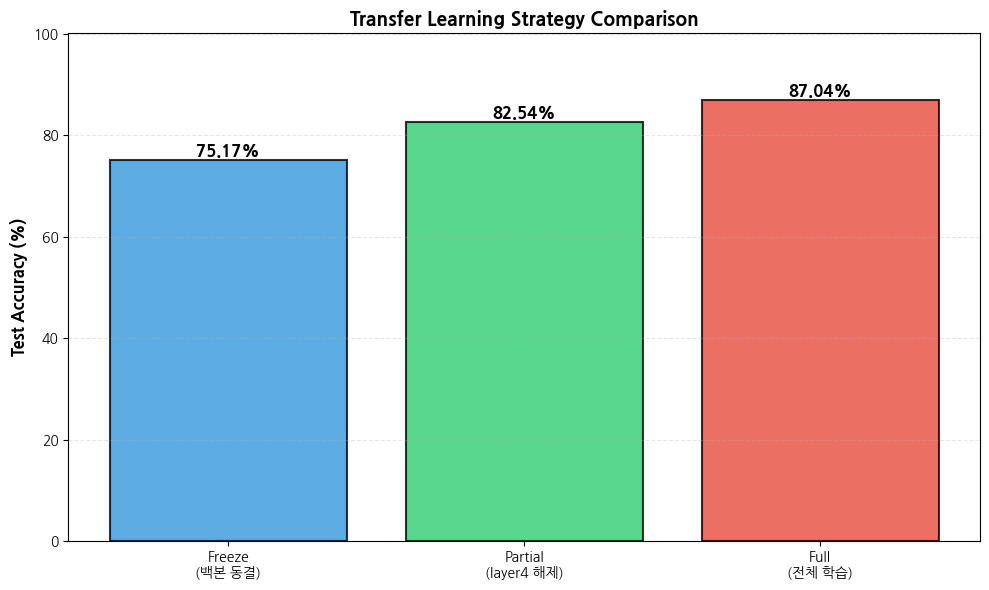

In [ ]:
# Matplotlib 라이브러리 임포트
import matplotlib.pyplot as plt

# 전략 이름과 정확도
strategies = ['Freeze\n(백본 동결)', 'Partial\n(layer4 해제)', 'Full\n(전체 학습)']
accuracies = [acc_freeze * 100, acc_partial * 100, acc_full * 100]

# 막대 그래프 생성
plt.figure(figsize=(10, 6))
bars = plt.bar(strategies, accuracies, color=['#3498db', '#2ecc71', '#e74c3c'],
               alpha=0.8, edgecolor='black', linewidth=1.5)

# 각 막대 위에 정확도 값 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# 그래프 설정
plt.ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
plt.title('Transfer Learning Strategy Comparison', fontsize=14, fontweight='bold')
plt.ylim([0, max(accuracies) * 1.15])  # Y축 범위 설정
plt.grid(True, axis='y', alpha=0.3, linestyle='--')

# 그래프 표시
plt.tight_layout()
plt.show()